# Attention model training

Five attention-based variants are compared: three pure self-attention encoders, a CNN with learned attention pooling and a hierarchical patch transformer. Model selection and classification analysis use only train and tune; the test fold remains untouched.

## 1. Setup and fixed folds

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from pytorch_timecourse_classification.analysis import (
    attention_rollout, plot_attention_overlay, plot_history_comparison,
    plot_training_history, summarize_history,
)
from pytorch_timecourse_classification.artifacts import artifact_dir_for, load_model, save_experiment_artifacts
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.models.attention import AttentionClassifier
from pytorch_timecourse_classification.models.cnn_attention_pooling import CNNAttentionPoolingClassifier
from pytorch_timecourse_classification.models.hierarchical_patch_transformer import HierarchicalPatchTransformerClassifier
from pytorch_timecourse_classification.training import TrainingConfig, train

In [2]:
train_fold, tune_fold, preprocessor = load_training_folds()
class_labels = np.arange(len(preprocessor.class_names))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for fold_name, fold in (("train", train_fold), ("tune", tune_fold)):
    counts = np.bincount(fold.targets.numpy(), minlength=len(class_labels))
    print(f"{fold_name:>5}: {tuple(fold.features.shape)}, {dict(zip(preprocessor.class_names, counts))}")
print(f"device: {device}")

train: (2790, 1, 289), {'0pM': np.int64(286), '1pM': np.int64(621), '2.5pM': np.int64(533), '5pM': np.int64(487), '25pM': np.int64(581), '100pM': np.int64(282)}
 tune: (349, 1, 289), {'0pM': np.int64(36), '1pM': np.int64(78), '2.5pM': np.int64(66), '5pM': np.int64(62), '25pM': np.int64(72), '100pM': np.int64(35)}
device: cuda


In [3]:
def create_model(model_type=AttentionClassifier, **config):
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    model = model_type(
        input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names),
        **config,
    )
    parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    print("model_config:", model.model_config)
    print(f"trainable parameters: {parameter_count:,}")
    return model, parameter_count


def fit_model(model, training_config):
    print(f"training_config: {training_config}")
    return train(
        model, train_fold.features, train_fold.targets,
        tune_fold.features, tune_fold.targets,
        config=training_config, device=device,
    )


def analyze_history(history):
    summary = summarize_history(history)
    print(summary)
    plot_training_history(history)
    return summary


def evaluate_tune(model):
    model.eval()
    with torch.no_grad():
        predictions = model(tune_fold.features.to(device)).argmax(dim=1).cpu().numpy()
    report = classification_report(
        tune_fold.targets.numpy(), predictions, labels=class_labels,
        target_names=preprocessor.class_names, zero_division=0, output_dict=True,
    )
    print(classification_report(
        tune_fold.targets.numpy(), predictions, labels=class_labels,
        target_names=preprocessor.class_names, zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        tune_fold.targets.numpy(), predictions, labels=class_labels,
        display_labels=preprocessor.class_names, xticks_rotation=35, cmap="Blues",
    )
    plt.tight_layout()
    return {"tune_macro_f1": report["macro avg"]["f1-score"]}


def save_and_verify(experiment_name, model, history):
    paths = save_experiment_artifacts(
        artifact_dir_for(experiment_name), model=model, history=history,
        preprocessor=preprocessor, training_targets=train_fold.targets,
        validation_targets=tune_fold.targets, device=device,
    )
    reloaded_model, checkpoint = load_model(paths.model, device=device)
    print(paths)
    print(f"reloaded {checkpoint['model_name']} at best epoch {checkpoint['best_epoch']}")
    return reloaded_model, paths

## 2. Variant A — compact mean-pooling attention

### 2.1 Model generation

A shallow pre-norm encoder is the low-variance reference. Weighted loss gives the two less frequent edge doses more influence.

In [4]:
compact_model, compact_parameter_count = create_model(
    embedding_dim=32, num_heads=4, num_layers=2, feedforward_dim=96,
    dropout=0.15, pooling="mean", norm_first=True,
)
compact_training_config = TrainingConfig(
    epochs=120, batch_size=64, learning_rate=5e-4, weight_decay=1e-4,
    scheduler_step_size=15, learning_rate_decay=0.80, patience=18,
    class_balance_strategy="weighted_loss",
)

model_config: {'input_length': 289, 'num_classes': 6, 'embedding_dim': 32, 'num_heads': 4, 'num_layers': 2, 'feedforward_dim': 96, 'dropout': 0.15, 'pooling': 'mean', 'norm_first': True}
trainable parameters: 21,574


### 2.2 Training

In [5]:
compact_history = fit_model(compact_model, compact_training_config)

training_config: TrainingConfig(epochs=120, batch_size=64, learning_rate=0.0005, weight_decay=0.0001, scheduler_step_size=15, learning_rate_decay=0.8, patience=18, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.69817, validation loss 1.46308, train accuracy 25.0%, validation accuracy 41.5%
epoch   5: train loss 1.11757, validation loss 1.15071, train accuracy 45.9%, validation accuracy 49.9%
epoch  10: train loss 1.07670, validation loss 1.09706, train accuracy 51.0%, validation accuracy 53.6%
epoch  15: train loss 1.00151, validation loss 1.05709, train accuracy 54.7%, validation accuracy 53.0%
epoch  20: train loss 0.93094, validation loss 0.97731, train accuracy 58.1%, validation accuracy 55.6%
epoch  25: train loss 0.91301, validation loss 0.95299, train accuracy 58.5%, validation accuracy 56.7%
epoch  30: train loss 0.89282, validation loss 0.95898, train accuracy 59.0%, validation accuracy 57.9%
epoch  35: t

### 2.3 History analysis

{'epochs_run': 77, 'best_epoch': 59, 'training_loss': 0.8506002875639119, 'tune_loss': 0.9170041162851547, 'training_accuracy': 0.6111111111111112, 'tune_accuracy': 0.5931232091690545, 'accuracy_gap': 0.017987901942056683}


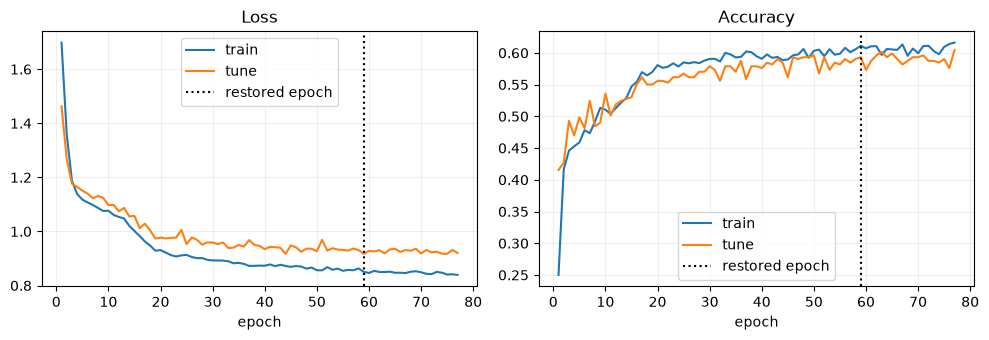

In [6]:
compact_history_summary = analyze_history(compact_history)

### 2.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.40      0.72      0.51        36
         1pM       0.50      0.26      0.34        78
       2.5pM       0.50      0.61      0.55        66
         5pM       0.71      0.55      0.62        62
        25pM       0.77      0.81      0.79        72
       100pM       0.71      0.83      0.76        35

    accuracy                           0.59       349
   macro avg       0.60      0.63      0.60       349
weighted avg       0.60      0.59      0.58       349



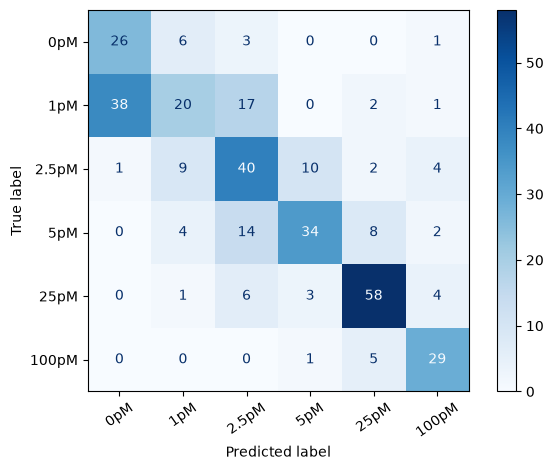

In [7]:
compact_tune_metrics = evaluate_tune(compact_model)

### 2.5 Saving artifacts

In [8]:
compact_reloaded, compact_paths = save_and_verify("attention_compact", compact_model, compact_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_compact/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_compact/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_compact/metadata.json'))
reloaded attention at best epoch 59


## 3. Variant B — regularized baseline attention

### 3.1 Model generation

The baseline retains a 64-dimensional representation but uses a wider feed-forward block, pre-norm layers and stronger optimizer regularization.

In [9]:
baseline_model, baseline_parameter_count = create_model(
    embedding_dim=64, num_heads=4, num_layers=3, feedforward_dim=192,
    dropout=0.20, pooling="mean", norm_first=True,
)
baseline_training_config = TrainingConfig(
    epochs=140, batch_size=48, learning_rate=3e-4, weight_decay=2e-4,
    scheduler_step_size=15, learning_rate_decay=0.80, patience=20,
    class_balance_strategy="weighted_loss",
)

model_config: {'input_length': 289, 'num_classes': 6, 'embedding_dim': 64, 'num_heads': 4, 'num_layers': 3, 'feedforward_dim': 192, 'dropout': 0.2, 'pooling': 'mean', 'norm_first': True}
trainable parameters: 125,830


### 3.2 Training

In [10]:
baseline_history = fit_model(baseline_model, baseline_training_config)

training_config: TrainingConfig(epochs=140, batch_size=48, learning_rate=0.0003, weight_decay=0.0002, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.73074, validation loss 1.41816, train accuracy 27.9%, validation accuracy 29.2%
epoch   5: train loss 1.11758, validation loss 1.15493, train accuracy 45.5%, validation accuracy 45.6%
epoch  10: train loss 1.07866, validation loss 1.10715, train accuracy 48.7%, validation accuracy 52.1%
epoch  15: train loss 0.99242, validation loss 1.02626, train accuracy 54.2%, validation accuracy 53.9%
epoch  20: train loss 0.93149, validation loss 0.99636, train accuracy 57.1%, validation accuracy 55.0%
epoch  25: train loss 0.90966, validation loss 0.98962, train accuracy 58.6%, validation accuracy 52.7%
epoch  30: train loss 0.88654, validation loss 0.96151, train accuracy 59.1%, validation accuracy 58.2%
epoch  35: t

### 3.3 History analysis

{'epochs_run': 122, 'best_epoch': 102, 'training_loss': 0.816003793029375, 'tune_loss': 0.8947630587826486, 'training_accuracy': 0.6186379928315412, 'tune_accuracy': 0.5931232091690545, 'accuracy_gap': 0.025514783662486717}


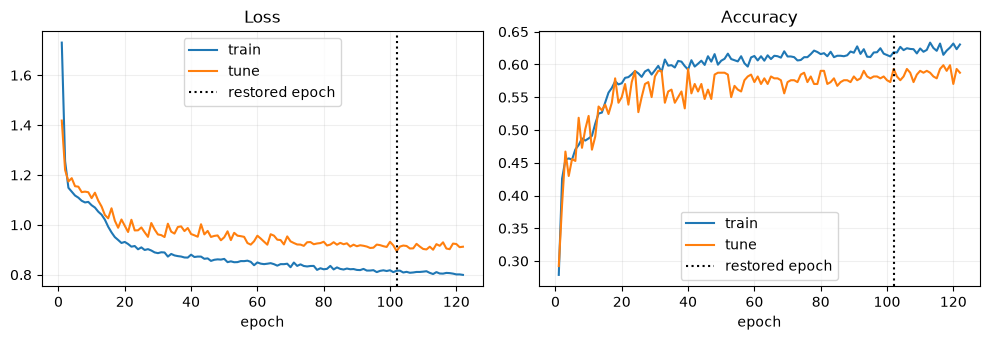

In [11]:
baseline_history_summary = analyze_history(baseline_history)

### 3.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.38      0.72      0.50        36
         1pM       0.53      0.24      0.33        78
       2.5pM       0.52      0.65      0.58        66
         5pM       0.76      0.50      0.60        62
        25pM       0.71      0.82      0.76        72
       100pM       0.76      0.83      0.79        35

    accuracy                           0.59       349
   macro avg       0.61      0.63      0.59       349
weighted avg       0.61      0.59      0.58       349



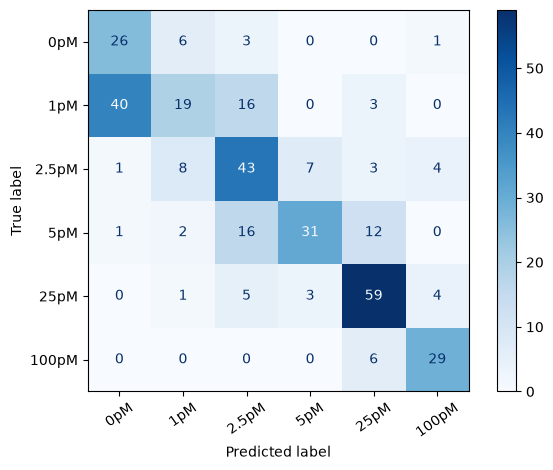

In [12]:
baseline_tune_metrics = evaluate_tune(baseline_model)

### 3.5 Saving artifacts

In [13]:
baseline_reloaded, baseline_paths = save_and_verify("attention_baseline", baseline_model, baseline_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_baseline/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_baseline/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_baseline/metadata.json'))
reloaded attention at best epoch 102


## 4. Variant C — wider CLS-token attention

### 4.1 Model generation

A learned CLS token lets attention construct a dedicated global summary instead of averaging every time point. The balanced sampler tests an alternative to loss weighting.

In [14]:
cls_model, cls_parameter_count = create_model(
    embedding_dim=96, num_heads=8, num_layers=4, feedforward_dim=384,
    dropout=0.25, pooling="cls", norm_first=True,
)
cls_training_config = TrainingConfig(
    epochs=160, batch_size=32, learning_rate=2e-4, weight_decay=5e-4,
    scheduler_step_size=20, learning_rate_decay=0.80, patience=22,
    class_balance_strategy="balanced_sampler",
)

model_config: {'input_length': 289, 'num_classes': 6, 'embedding_dim': 96, 'num_heads': 8, 'num_layers': 4, 'feedforward_dim': 384, 'dropout': 0.25, 'pooling': 'cls', 'norm_first': True}
trainable parameters: 448,422


### 4.2 Training

In [15]:
cls_history = fit_model(cls_model, cls_training_config)

training_config: TrainingConfig(epochs=160, batch_size=32, learning_rate=0.0002, weight_decay=0.0005, scheduler_step_size=20, learning_rate_decay=0.8, patience=22, report_every=5, random_seed=42, class_balance_strategy='balanced_sampler', gradient_clip_norm=1.0)
epoch   1: train loss 1.30408, validation loss 1.23608, train accuracy 41.9%, validation accuracy 39.5%
epoch   5: train loss 1.06894, validation loss 1.12414, train accuracy 52.4%, validation accuracy 53.9%
epoch  10: train loss 1.00034, validation loss 1.03475, train accuracy 57.6%, validation accuracy 55.3%
epoch  15: train loss 0.98869, validation loss 1.02086, train accuracy 57.5%, validation accuracy 55.3%
epoch  20: train loss 0.92972, validation loss 1.02874, train accuracy 60.2%, validation accuracy 53.0%
epoch  25: train loss 0.89943, validation loss 0.95928, train accuracy 62.0%, validation accuracy 54.2%
epoch  30: train loss 0.90361, validation loss 0.99666, train accuracy 61.4%, validation accuracy 55.3%
epoch  35

### 4.3 History analysis

{'epochs_run': 86, 'best_epoch': 64, 'training_loss': 0.8363835349305129, 'tune_loss': 0.8957938907139622, 'training_accuracy': 0.6329749103942652, 'tune_accuracy': 0.5787965616045845, 'accuracy_gap': 0.05417834878968075}


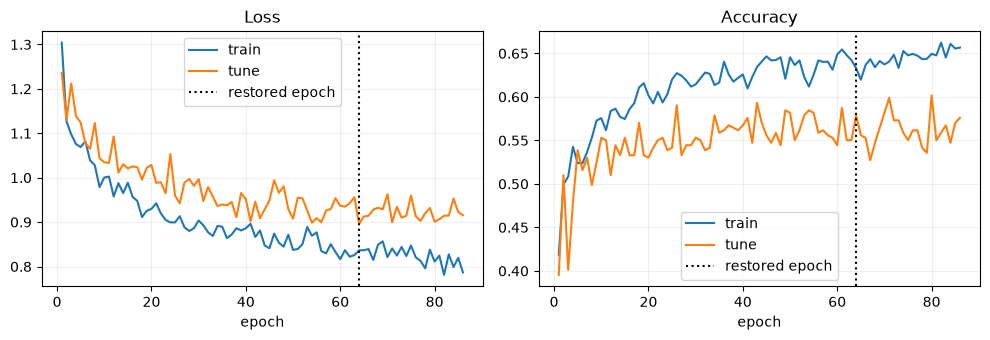

In [16]:
cls_history_summary = analyze_history(cls_history)

### 4.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.40      0.75      0.52        36
         1pM       0.52      0.31      0.39        78
       2.5pM       0.52      0.45      0.48        66
         5pM       0.57      0.63      0.60        62
        25pM       0.74      0.72      0.73        72
       100pM       0.77      0.86      0.81        35

    accuracy                           0.58       349
   macro avg       0.59      0.62      0.59       349
weighted avg       0.59      0.58      0.57       349



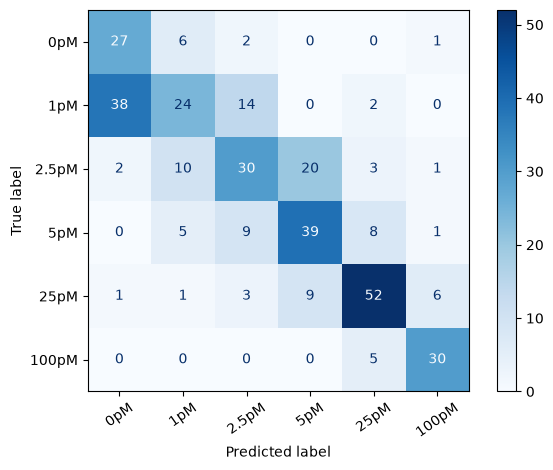

In [17]:
cls_tune_metrics = evaluate_tune(cls_model)

### 4.5 Saving artifacts

In [18]:
cls_reloaded, cls_paths = save_and_verify("attention_cls", cls_model, cls_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cls/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cls/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cls/metadata.json'))
reloaded attention at best epoch 64


## 5. Variant D — CNN with attention pooling

A convolutional encoder first converts local trajectory motifs into a shorter token sequence. A learned scalar attention score then weights these tokens before classification. This combines the locality and shift tolerance of CNN features with an interpretable, data-dependent temporal pooling step.

```text
time course → strided CNN → temporal feature tokens → softmax attention weights
                                                   ↓ weighted sum → classifier
```

### 5.1 Model generation

In [19]:
cnn_pooling_model, cnn_pooling_parameter_count = create_model(
    CNNAttentionPoolingClassifier, channels=(32, 64, 96),
    kernel_sizes=(9, 7, 5), strides=(2, 2, 1),
    attention_hidden_dim=64, classifier_hidden_dim=64, dropout=0.30,
)
cnn_pooling_training_config = TrainingConfig(
    epochs=140, batch_size=128, learning_rate=4e-4, weight_decay=5e-4,
    scheduler_step_size=15, learning_rate_decay=0.80, patience=20,
    class_balance_strategy="weighted_loss",
)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (32, 64, 96), 'kernel_sizes': (9, 7, 5), 'strides': (2, 2, 1), 'attention_hidden_dim': 64, 'classifier_hidden_dim': 64, 'dropout': 0.3}
trainable parameters: 58,982


### 5.2 Training

In [20]:
cnn_pooling_history = fit_model(cnn_pooling_model, cnn_pooling_training_config)

training_config: TrainingConfig(epochs=140, batch_size=128, learning_rate=0.0004, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.8, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.51877, validation loss 1.64613, train accuracy 30.2%, validation accuracy 20.6%
epoch   5: train loss 1.12811, validation loss 1.13424, train accuracy 46.3%, validation accuracy 47.6%
epoch  10: train loss 1.02876, validation loss 1.08562, train accuracy 52.5%, validation accuracy 48.4%
epoch  15: train loss 0.96812, validation loss 0.98141, train accuracy 55.4%, validation accuracy 56.2%
epoch  20: train loss 0.93074, validation loss 0.98665, train accuracy 57.7%, validation accuracy 57.9%
epoch  25: train loss 0.92106, validation loss 0.90071, train accuracy 59.6%, validation accuracy 62.8%
epoch  30: train loss 0.90510, validation loss 0.88769, train accuracy 59.4%, validation accuracy 61.3%
epoch  35: 

### 5.3 History analysis

If this hybrid converges faster or generalizes better than point-wise self-attention, the convolutional locality prior is useful. A very peaked pooling distribution with a widening train–tune gap would suggest that the model is memorizing a few unstable locations.

{'epochs_run': 140, 'best_epoch': 128, 'training_loss': 0.74769022725389, 'tune_loss': 0.7780357286718308, 'training_accuracy': 0.6709677419354839, 'tune_accuracy': 0.6561604584527221, 'accuracy_gap': 0.014807283482761835}


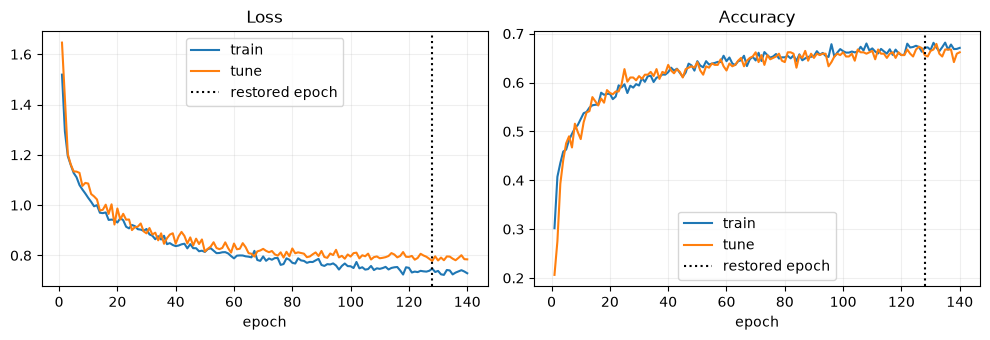

In [21]:
cnn_pooling_history_summary = analyze_history(cnn_pooling_history)

### 5.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.44      0.61      0.51        36
         1pM       0.65      0.58      0.61        78
       2.5pM       0.65      0.59      0.62        66
         5pM       0.59      0.60      0.59        62
        25pM       0.80      0.72      0.76        72
       100pM       0.81      0.97      0.88        35

    accuracy                           0.66       349
   macro avg       0.66      0.68      0.66       349
weighted avg       0.66      0.66      0.66       349



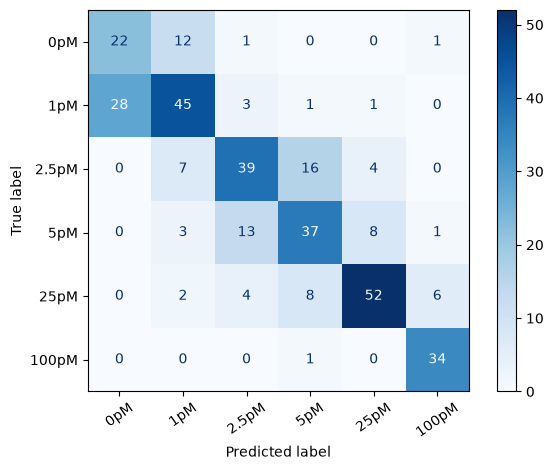

In [22]:
cnn_pooling_tune_metrics = evaluate_tune(cnn_pooling_model)

### 5.5 Saving artifacts

In [23]:
cnn_pooling_reloaded, cnn_pooling_paths = save_and_verify(
    "attention_cnn_pooling", cnn_pooling_model, cnn_pooling_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cnn_pooling/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cnn_pooling/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_cnn_pooling/metadata.json'))
reloaded cnn_attention_pooling at best epoch 128


## 6. Variant E — hierarchical patch transformer

Non-overlapping temporal patches replace individual time points as tokens. A first transformer models relations between local patches; neighboring representations are then merged and a second transformer models the trajectory at a coarser scale. This reduces the attention sequence length and explicitly separates local from long-range structure.

```text
time course → patch embedding → fine transformer → merge neighboring patches
                                                   ↓
                              coarse transformer → mean pool → classifier
```

### 6.1 Model generation

In [24]:
hierarchical_model, hierarchical_parameter_count = create_model(
    HierarchicalPatchTransformerClassifier, patch_size=8,
    embedding_dim=48, num_heads=4, stage1_layers=2, stage2_layers=2,
    feedforward_multiplier=3, dropout=0.20, norm_first=True,
)
hierarchical_training_config = TrainingConfig(
    epochs=150, batch_size=64, learning_rate=3e-4, weight_decay=5e-4,
    scheduler_step_size=18, learning_rate_decay=0.80, patience=22,
    class_balance_strategy="weighted_loss",
)

model_config: {'input_length': 289, 'num_classes': 6, 'patch_size': 8, 'embedding_dim': 48, 'num_heads': 4, 'stage1_layers': 2, 'stage2_layers': 2, 'feedforward_multiplier': 3, 'dropout': 0.2, 'norm_first': True}
trainable parameters: 244,566


### 6.2 Training

In [25]:
hierarchical_history = fit_model(hierarchical_model, hierarchical_training_config)

training_config: TrainingConfig(epochs=150, batch_size=64, learning_rate=0.0003, weight_decay=0.0005, scheduler_step_size=18, learning_rate_decay=0.8, patience=22, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.32967, validation loss 1.12509, train accuracy 37.7%, validation accuracy 48.1%
epoch   5: train loss 0.91756, validation loss 0.90983, train accuracy 57.8%, validation accuracy 62.2%
epoch  10: train loss 0.83252, validation loss 0.87529, train accuracy 62.5%, validation accuracy 59.6%
epoch  15: train loss 0.77981, validation loss 0.85517, train accuracy 64.3%, validation accuracy 59.3%
epoch  20: train loss 0.74057, validation loss 0.81104, train accuracy 65.8%, validation accuracy 60.7%
epoch  25: train loss 0.71062, validation loss 0.84766, train accuracy 67.9%, validation accuracy 59.0%
epoch  30: train loss 0.68250, validation loss 0.82696, train accuracy 67.8%, validation accuracy 61.9%
epoch  35: t

### 6.3 History analysis

A gain over full-resolution attention would indicate that patch-level structure is sufficient and the hierarchy regularizes useful long-range interactions. Underfitting may mean that patches are too wide; overfitting may require fewer layers or a smaller second-stage embedding.

{'epochs_run': 48, 'best_epoch': 26, 'training_loss': 0.7022304338366328, 'tune_loss': 0.7851541120889877, 'training_accuracy': 0.668100358422939, 'tune_accuracy': 0.6475644699140402, 'accuracy_gap': 0.02053588850889887}


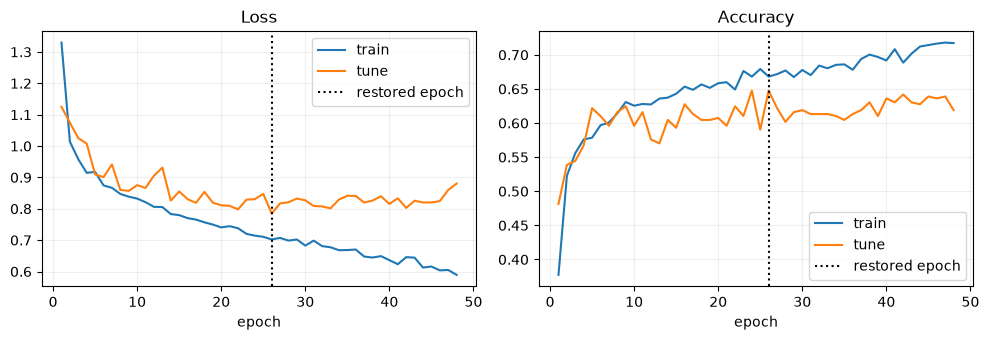

In [26]:
hierarchical_history_summary = analyze_history(hierarchical_history)

### 6.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.42      0.67      0.52        36
         1pM       0.55      0.40      0.46        78
       2.5pM       0.60      0.62      0.61        66
         5pM       0.69      0.68      0.68        62
        25pM       0.82      0.83      0.83        72
       100pM       0.82      0.80      0.81        35

    accuracy                           0.65       349
   macro avg       0.65      0.67      0.65       349
weighted avg       0.66      0.65      0.65       349



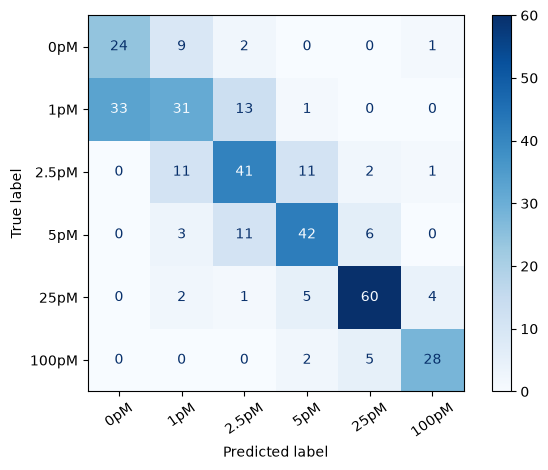

In [27]:
hierarchical_tune_metrics = evaluate_tune(hierarchical_model)

### 6.5 Saving artifacts

In [28]:
hierarchical_reloaded, hierarchical_paths = save_and_verify(
    "attention_hierarchical_patch", hierarchical_model, hierarchical_history
)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_hierarchical_patch/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_hierarchical_patch/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/attention_hierarchical_patch/metadata.json'))
reloaded hierarchical_patch_transformer at best epoch 26


## 7. Direct comparison

Use tune macro-F1 as the primary metric and tune loss as a stability check. The larger model is justified only if its improvement survives repeated seeds.

In [29]:
comparison = pd.DataFrame([
    {"variant": "compact", "parameters": compact_parameter_count, **compact_history_summary, **compact_tune_metrics},
    {"variant": "baseline", "parameters": baseline_parameter_count, **baseline_history_summary, **baseline_tune_metrics},
    {"variant": "cls", "parameters": cls_parameter_count, **cls_history_summary, **cls_tune_metrics},
    {"variant": "cnn_pooling", "parameters": cnn_pooling_parameter_count, **cnn_pooling_history_summary, **cnn_pooling_tune_metrics},
    {"variant": "hierarchical", "parameters": hierarchical_parameter_count, **hierarchical_history_summary, **hierarchical_tune_metrics},
]).set_index("variant")
comparison.round(4)

,parameters,epochs_run,best_epoch,training_loss,tune_loss,training_accuracy,tune_accuracy,accuracy_gap,tune_macro_f1
variant,,,,,,,,,
compact,21574,77,59,0.8506,0.9170,0.6111,0.5931,0.0180,0.5954
baseline,125830,122,102,0.8160,0.8948,0.6186,0.5931,0.0255,0.5947
cls,448422,86,64,0.8364,0.8958,0.6330,0.5788,0.0542,0.5889
cnn_pooling,58982,140,128,0.7477,0.7780,0.6710,0.6562,0.0148,0.6629
hierarchical,244566,48,26,0.7022,0.7852,0.6681,0.6476,0.0205,0.6521


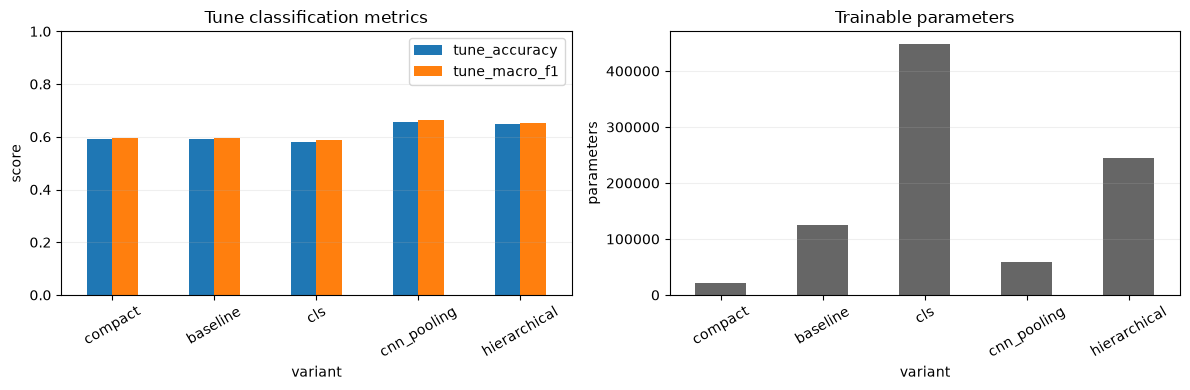

In [30]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison[["tune_accuracy", "tune_macro_f1"]].plot.bar(ax=axes[0], ylim=(0, 1), rot=30)
axes[0].set(title="Tune classification metrics", ylabel="score")
comparison["parameters"].plot.bar(ax=axes[1], color="0.4", rot=30)
axes[1].set(title="Trainable parameters", ylabel="parameters")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

## 8. Project attention back to the time courses

Raw attention weights are not automatically faithful feature attributions. As a diagnostic, attention rollout averages heads, includes residual connections and composes attention across layers. For CLS pooling, the CLS-to-timepoint influence is used; for mean pooling, influence is averaged over output timepoints. The resulting values are overlaid on representative tune trajectories and summarized per class. This rollout comparison is restricted to the three full-resolution self-attention variants because CNN pooling weights and hierarchical stage attentions have different meanings and resolutions.

In [31]:
attention_models = {"compact": compact_model, "baseline": baseline_model, "cls": cls_model}
rollout_variants = list(attention_models)
best_variant = comparison.loc[rollout_variants, "tune_macro_f1"].idxmax()
analysis_model = attention_models[best_variant]
analysis_model.eval()
with torch.no_grad():
    tune_predictions = analysis_model(tune_fold.features.to(device)).argmax(dim=1).cpu()
print(f"attention analysis uses tune-selected variant: {best_variant}")

attention analysis uses tune-selected variant: compact


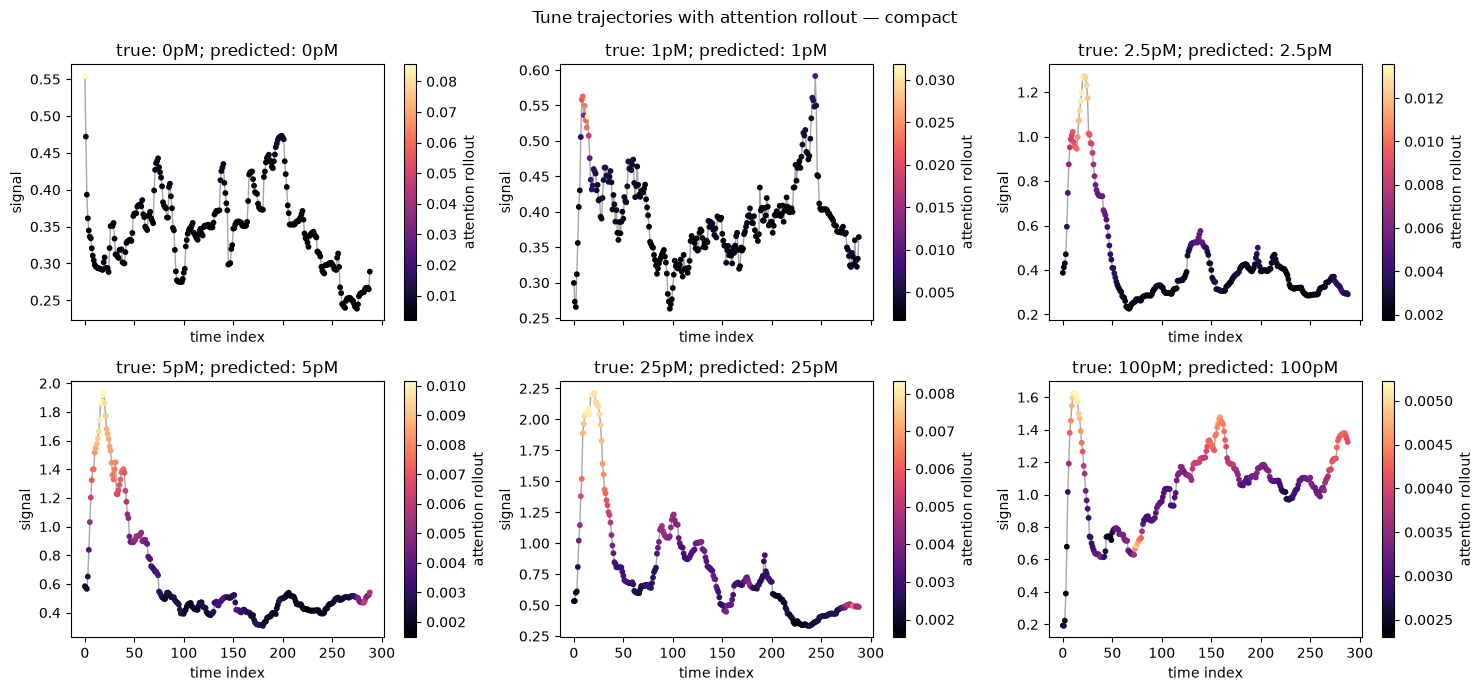

In [32]:
example_indices = []
for class_index in class_labels:
    class_indices = torch.where(tune_fold.targets == class_index)[0]
    correct_indices = class_indices[tune_predictions[class_indices] == class_index]
    example_indices.append(int(correct_indices[0] if len(correct_indices) else class_indices[0]))

with torch.no_grad():
    _, example_attention = analysis_model.forward_with_attention(
        tune_fold.features[example_indices].to(device)
    )
    example_importance = attention_rollout(
        example_attention, pooling=analysis_model.pooling
    ).cpu().numpy()

figure, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for axis, sample_index, importance in zip(axes.flat, example_indices, example_importance):
    true_name = preprocessor.class_names[int(tune_fold.targets[sample_index])]
    predicted_name = preprocessor.class_names[int(tune_predictions[sample_index])]
    plot_attention_overlay(
        tune_fold.trajectories[sample_index], importance, axis=axis,
        title=f"true: {true_name}; predicted: {predicted_name}",
    )
figure.suptitle(f"Tune trajectories with attention rollout — {best_variant}")
figure.tight_layout()

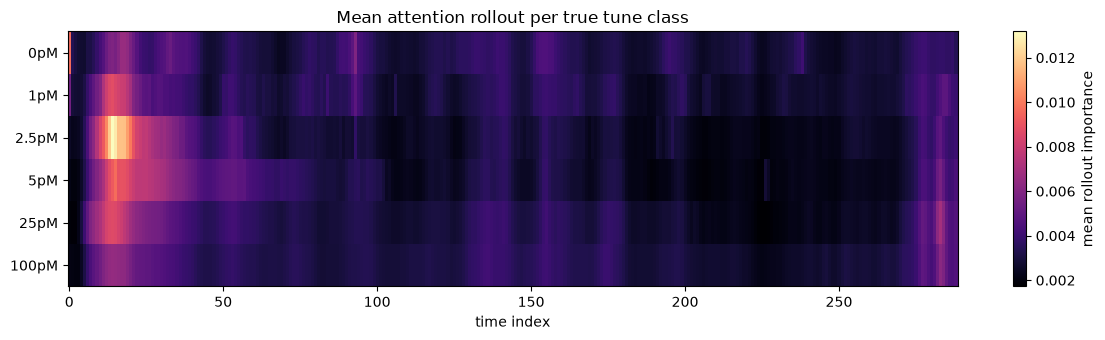

In [33]:
rollout_batches = []
with torch.no_grad():
    for start in range(0, len(tune_fold.features), 16):
        _, batch_attention = analysis_model.forward_with_attention(
            tune_fold.features[start:start + 16].to(device)
        )
        rollout_batches.append(
            attention_rollout(batch_attention, pooling=analysis_model.pooling).cpu()
        )
all_importance = torch.cat(rollout_batches).numpy()
class_mean_importance = np.vstack([
    all_importance[tune_fold.targets.numpy() == class_index].mean(axis=0)
    for class_index in class_labels
])
figure, axis = plt.subplots(figsize=(12, 3.5))
image = axis.imshow(class_mean_importance, aspect="auto", cmap="magma")
axis.set(yticks=class_labels, yticklabels=preprocessor.class_names, xlabel="time index", title="Mean attention rollout per true tune class")
figure.colorbar(image, ax=axis, label="mean rollout importance")
figure.tight_layout()

## 9. Interpretation and next steps

Interpret the variants in two stages. First inspect train and tune loss: high, parallel plateaus indicate underfitting or unsuccessful optimization, whereas a falling train loss combined with a rising tune loss and a widening accuracy gap indicates overfitting. The compact model is useful as a variance-controlled reference. The baseline should improve tune macro-F1 without opening a large gap. The CLS model is worthwhile only if its learned global summary improves tune performance rather than training performance alone. CNN attention pooling tests whether a local convolutional prior is more sample-efficient, while the hierarchical transformer tests whether patching and coarse-to-fine attention improve long-range modeling.

Then inspect the confusion matrices. Weighted loss and balanced sampling are successful only if they recover the less frequent 0 pM and 100 pM classes without broadly degrading the intermediate doses. Macro-F1 is therefore more informative than accuracy for model selection. Tune loss remains important because two models with similar accuracy can differ substantially in confidence and calibration.

Next, repeat each variant with several seeds and report mean and standard deviation of tune macro-F1. For CNN pooling, project its token weights back to time intervals and check stability across seeds. For the hierarchical transformer, vary patch size and compare fine-stage with coarse-stage attention rather than mixing their resolutions. If only the CLS model overfits, reduce embedding/feed-forward width or increase weight decay and dropout. Compare attention-based views against gradient attribution or input occlusion: stable agreement is stronger evidence than one attractive attention plot. Further useful checks are probability calibration and group-aware folds if trajectories from one experiment or replicate are correlated. Select the family winner on tune only; use test once in the subsequent comparison notebook.

## 10. Training-history comparison

The four panels compare train and tune loss and accuracy for all five attention variants. Each dot marks the checkpoint epoch restored after early stopping.

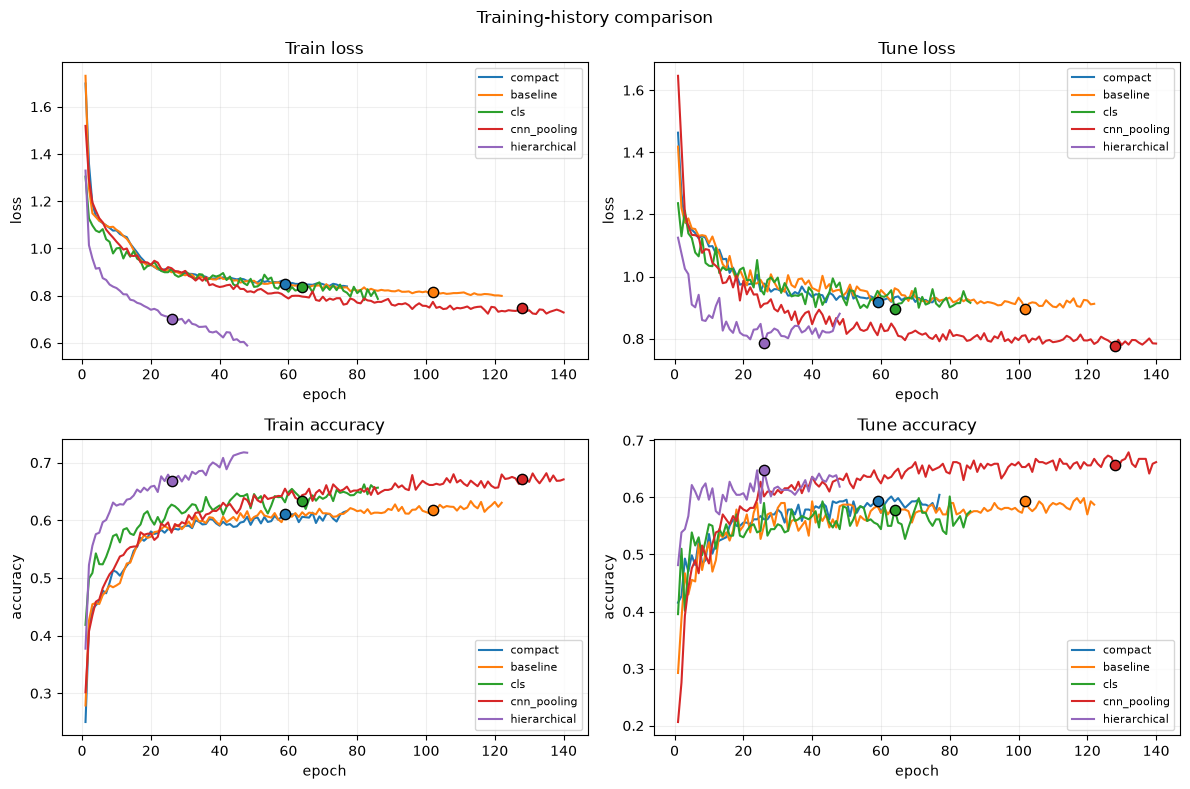

In [34]:
history_comparison_figure = plot_history_comparison({
    "compact": compact_history,
    "baseline": baseline_history,
    "cls": cls_history,
    "cnn_pooling": cnn_pooling_history,
    "hierarchical": hierarchical_history,
})